In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parthdande/timeseries-weather-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\sable\.cache\kagglehub\datasets\parthdande\timeseries-weather-dataset\versions\2


In [81]:
import os
print(os.listdir(path))

['Weather_dataset.csv', 'Weather_Data_1980_2024(hourly).csv']


In [224]:
import time

In [225]:
file = os.path.join(path, "Weather_Data_1980_2024(hourly).csv")
start = time.time()
df = pd.read_csv(file)
end = time.time() - start
print("time to load file:",end)
mem = df.memory_usage(deep=True).sum()
print(f"memory usage: {mem/1024**2:.2f} MB")

time to load file: 1.2657690048217773
memory usage: 71.69 MB


In [226]:
df.shape

(389496, 17)

In [85]:
df.head(2)

,time,temperature,relative_humidity,dew_point,precipitation (mm),rain (mm),snowfall (cm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction,is_Day
0,1980-01-01T00:00,12.7,83,10.0,0.0,0.0,0,1012.8,945.1,1,1,0,0,0.25,7.5,235,0
1,1980-01-01T01:00,12.9,82,9.9,0.0,0.0,0,1012.2,944.5,4,4,0,0,0.26,7.9,231,0


In [86]:
print(df.describe())

         temperature  relative_humidity      dew_point  precipitation (mm)  \
count  389496.000000      389496.000000  389496.000000       389496.000000   
mean       24.130906          63.946035      15.233168            0.114465   
std         4.996178          25.821642       6.103542            0.573517   
min         7.100000           6.000000     -11.800000            0.000000   
25%        21.500000          42.000000      10.200000            0.000000   
50%        23.400000          67.000000      16.100000            0.000000   
75%        27.000000          89.000000      21.100000            0.000000   
max        41.700000         100.000000      25.400000           29.500000   

           rain (mm)  snowfall (cm)  pressure_msl (hPa)  \
count  389496.000000       389496.0       389496.000000   
mean        0.114465            0.0         1010.373729   
std         0.573517            0.0            4.182607   
min         0.000000            0.0          991.100000   
25

In [87]:
df.isnull().sum()

time                             0
temperature                      0
relative_humidity                0
dew_point                        0
precipitation (mm)               0
rain (mm)                        0
snowfall (cm)                    0
pressure_msl (hPa)               0
surface_pressure (hPa)           0
cloud_cover (%)                  0
cloud_cover_low (%)              0
cloud_cover_mid (%)              0
cloud_cover_high (%)             0
vapour_pressure_deficit (kPa)    0
wind_speed_10m (km/h)            0
wind_direction                   0
is_Day                           0
dtype: int64

In [88]:
df.columns

Index(['time', 'temperature', 'relative_humidity', 'dew_point',
       'precipitation (mm)', 'rain (mm)', 'snowfall (cm)',
       'pressure_msl (hPa)', 'surface_pressure (hPa)', 'cloud_cover (%)',
       'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'vapour_pressure_deficit (kPa)', 'wind_speed_10m (km/h)',
       'wind_direction', 'is_Day'],
      dtype='str')

In [233]:
df['time'] = pd.to_datetime(df['time'])

In [227]:
df = df.drop(columns=['is_Day', 'snowfall (cm)'])


In [228]:
df.head(2)

,time,temperature,relative_humidity,dew_point,precipitation (mm),rain (mm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction
0,1980-01-01T00:00,12.7,83,10.0,0.0,0.0,1012.8,945.1,1,1,0,0,0.25,7.5,235
1,1980-01-01T01:00,12.9,82,9.9,0.0,0.0,1012.2,944.5,4,4,0,0,0.26,7.9,231


In [229]:
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count >= 1:
        print(f"--- Column: {col} ({unique_count} unique values) ---")
        print(df[col].unique()[:10]) 
        print("\n")

--- Column: time (389496 unique values) ---
<StringArray>
['1980-01-01T00:00', '1980-01-01T01:00', '1980-01-01T02:00',
 '1980-01-01T03:00', '1980-01-01T04:00', '1980-01-01T05:00',
 '1980-01-01T06:00', '1980-01-01T07:00', '1980-01-01T08:00',
 '1980-01-01T09:00']
Length: 10, dtype: str


--- Column: temperature (342 unique values) ---
[12.7 12.9 13.2 15.9 19.4 21.7 23.5 24.  24.8 25.1]


--- Column: relative_humidity (95 unique values) ---
[83 82 78 67 56 46 48 45 44 47]


--- Column: dew_point (339 unique values) ---
[10.   9.9 10.2 12.  13.1 12.4 11.4 12.5 12.1 12.3]


--- Column: precipitation (mm) (203 unique values) ---
[0.  0.1 0.4 0.2 0.9 0.6 0.7 0.8 0.5 0.3]


--- Column: rain (mm) (203 unique values) ---
[0.  0.1 0.4 0.2 0.9 0.6 0.7 0.8 0.5 0.3]


--- Column: pressure_msl (hPa) (309 unique values) ---
[1012.8 1012.2 1012.3 1013.5 1014.6 1014.9 1013.4 1011.2 1010.6 1011. ]


--- Column: surface_pressure (hPa) (288 unique values) ---
[945.1 944.5 944.7 946.4 948.2 949.  949.1 948.

In [230]:
df.columns

Index(['time', 'temperature', 'relative_humidity', 'dew_point',
       'precipitation (mm)', 'rain (mm)', 'pressure_msl (hPa)',
       'surface_pressure (hPa)', 'cloud_cover (%)', 'cloud_cover_low (%)',
       'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'vapour_pressure_deficit (kPa)', 'wind_speed_10m (km/h)',
       'wind_direction'],
      dtype='str')

In [234]:
daily = df.resample('D', on = 'time').mean().reset_index()

In [235]:
daily.head(2)

,time,temperature,relative_humidity,dew_point,precipitation (mm),rain (mm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction
0,1980-01-01,19.616667,71.041667,13.591667,0.0,0.0,1012.670833,946.462500,39.291667,38.125000,17.958333,0.083333,0.765833,8.833333,261.541667
1,1980-01-02,18.925000,69.041667,12.145833,0.0,0.0,1013.183333,946.804167,16.708333,18.583333,0.000000,0.000000,0.799167,7.770833,247.708333


# Visualization

In [96]:
plt.style.use('ggplot')

# Relationship,Type,Scientific Suggestion
# Humidity & Clouds,High Positive,Clouds are the primary indicator of high moisture levels.
# Humidity & VPD,High Negative,Evaporation is physically limited when humidity is high.
# Pressure & Clouds,Moderate Negative,Low-pressure systems are the main drivers of cloudy/stormy weather.


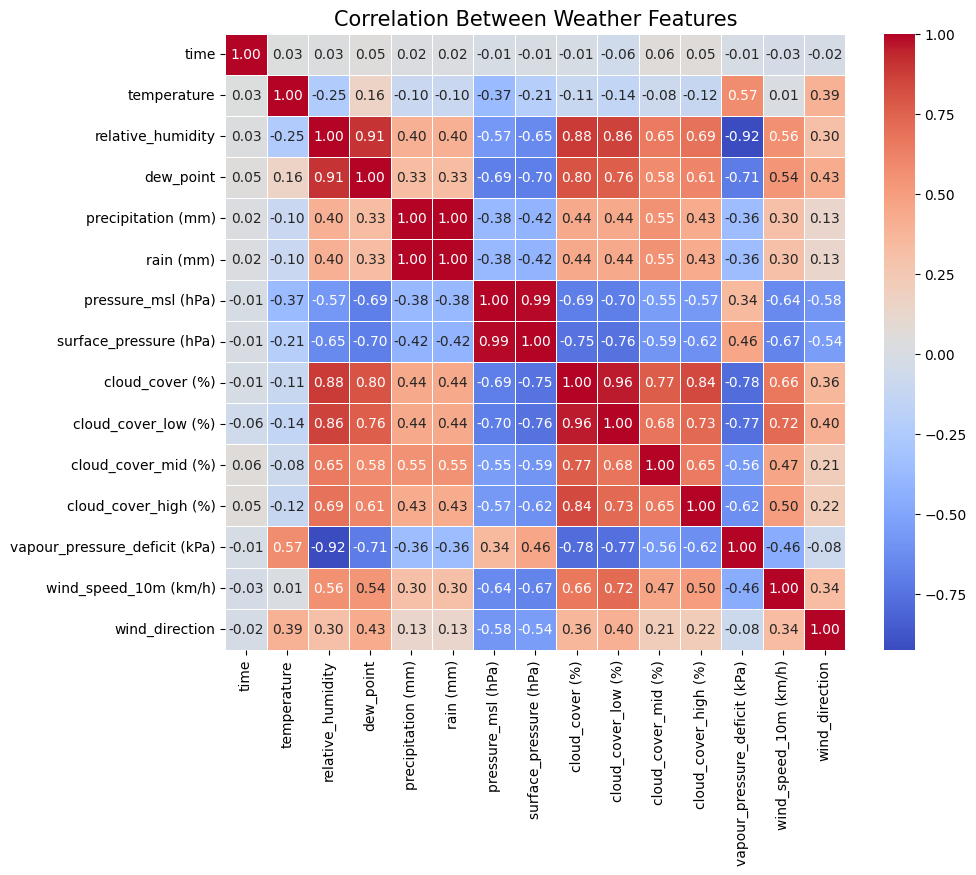

In [236]:
plt.style.use('default')
cor = daily.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Weather Features", fontsize=15)
plt.show()


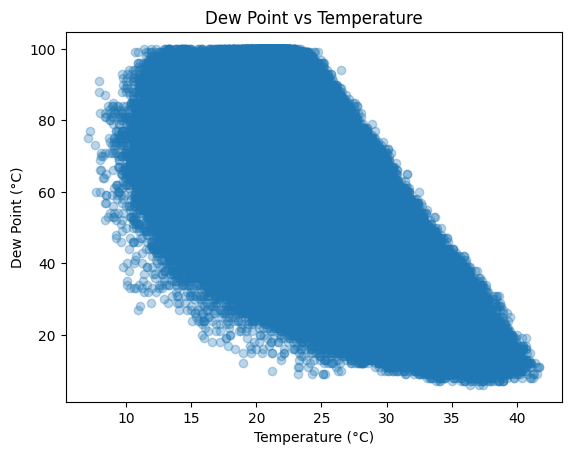

In [237]:
plt.scatter(df['temperature'], df['relative_humidity'], alpha=0.3)
plt.xlabel("Temperature (°C)")
plt.ylabel("Dew Point (°C)")
plt.title("Dew Point vs Temperature")
plt.show()


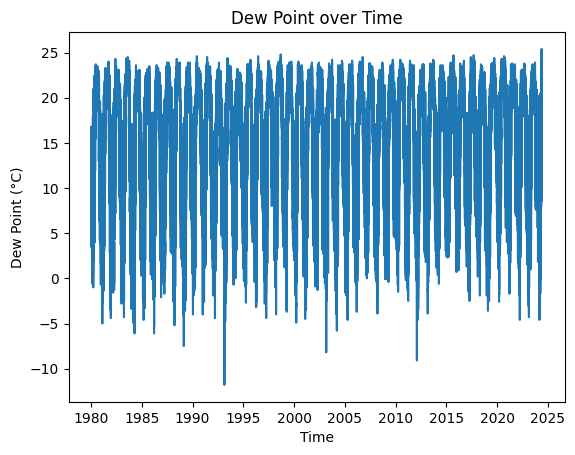

In [238]:
plt.plot(df['time'], df['dew_point'])
plt.title("Dew Point over Time")
plt.xlabel("Time")
plt.ylabel("Dew Point (°C)")
plt.show()


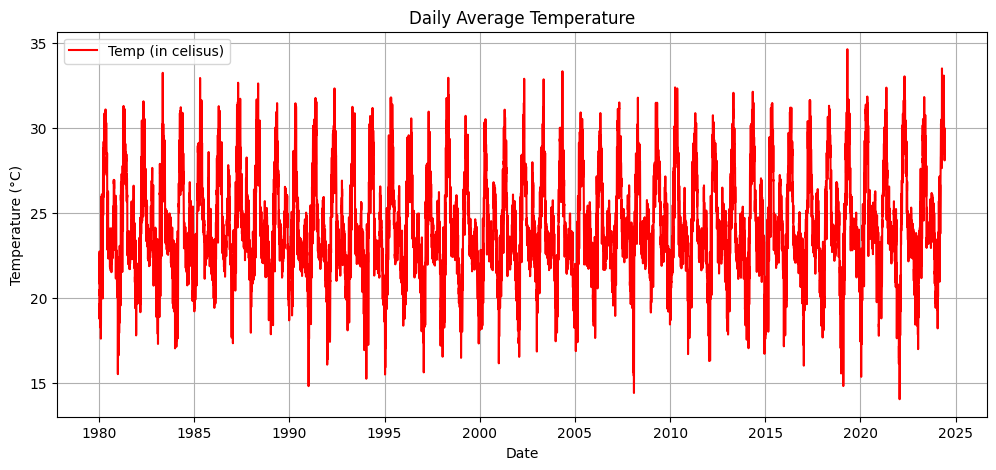

In [239]:
plt.figure(figsize = (12, 5))
plt.plot(daily['time'], daily['temperature'], color = 'red', label = 'Temp (in celisus)')
plt.title("Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.show()

In [240]:
df['temperature'].max()

np.float64(41.7)

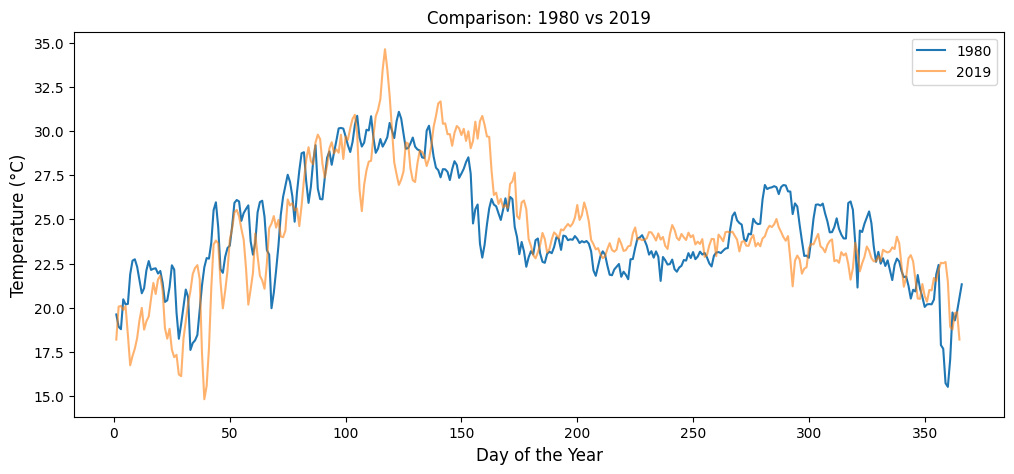

In [241]:
daily['day_of_year'] = daily['time'].dt.dayofyear

plt.figure(figsize=(12, 5))
plt.plot(daily[daily['time'].dt.year == 1980]['day_of_year'], 
         daily[daily['time'].dt.year == 1980]['temperature'], label='1980')

plt.plot(daily[daily['time'].dt.year == 2019]['day_of_year'], 
         daily[daily['time'].dt.year == 2019]['temperature'], label='2019', alpha=0.6)

plt.xlabel("Day of the Year", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.legend()
plt.title("Comparison: 1980 vs 2019")
plt.show()

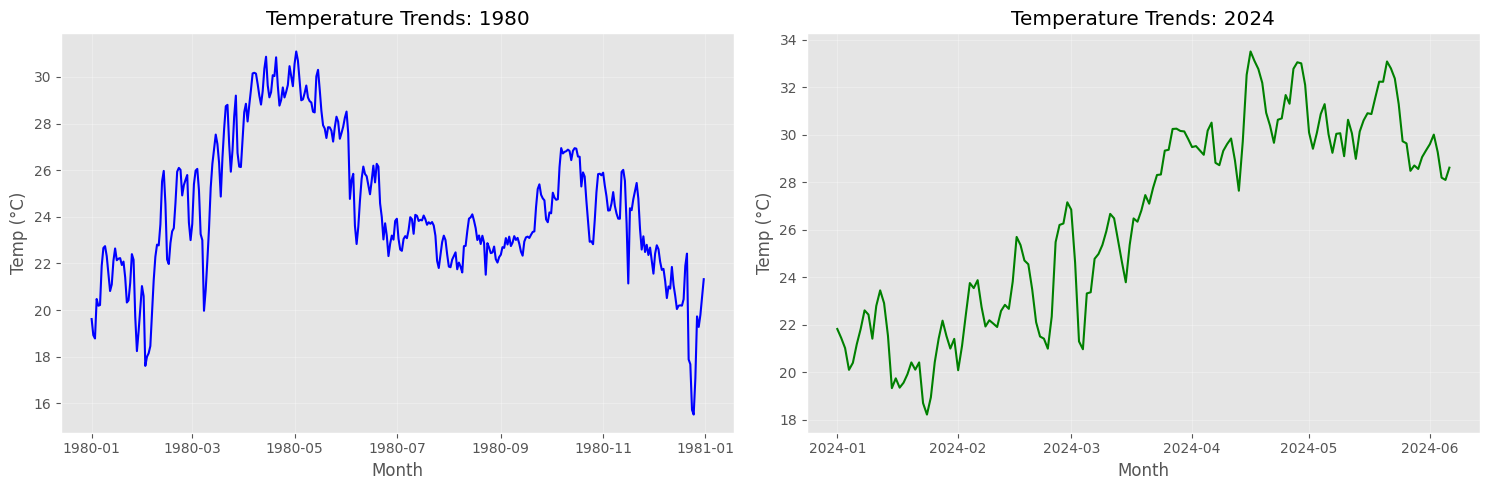

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_1980 = daily[daily['time'].dt.year == 1980]
df_2024 = daily[daily['time'].dt.year == 2024]

# First Plot (1980)
axes[0].plot(df_1980['time'], df_1980['temperature'], color='blue', label='Temp 1980')
axes[0].set_title("Temperature Trends: 1980")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Temp (°C)")
axes[0].grid(True, alpha=0.3)

# Second Plot (2025)
axes[1].plot(df_2024['time'], df_2024['temperature'], color='green', label='Temp 2025')
axes[1].set_title("Temperature Trends: 2024")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Temp (°C)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

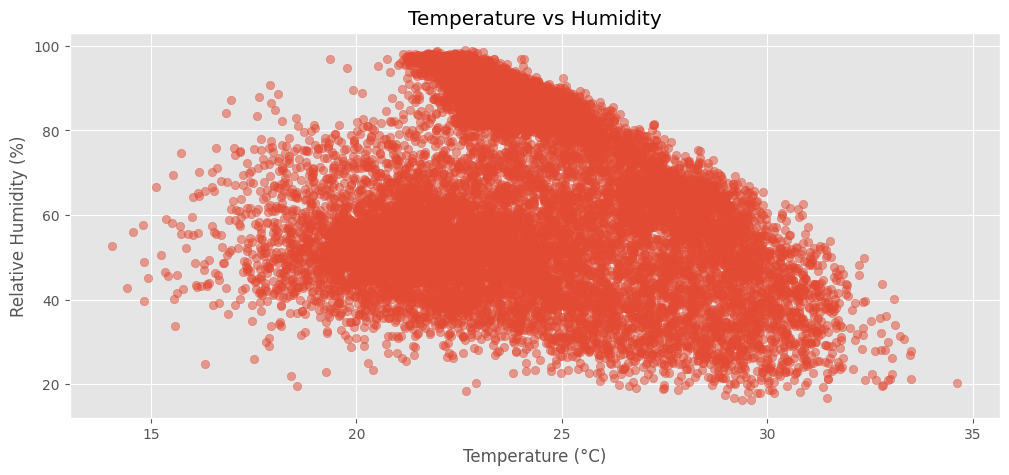

In [100]:
plt.figure(figsize=(12, 5))
plt.scatter(daily['temperature'], daily['relative_humidity'], alpha=0.5)
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()


In [118]:
plt.style.use('bmh')

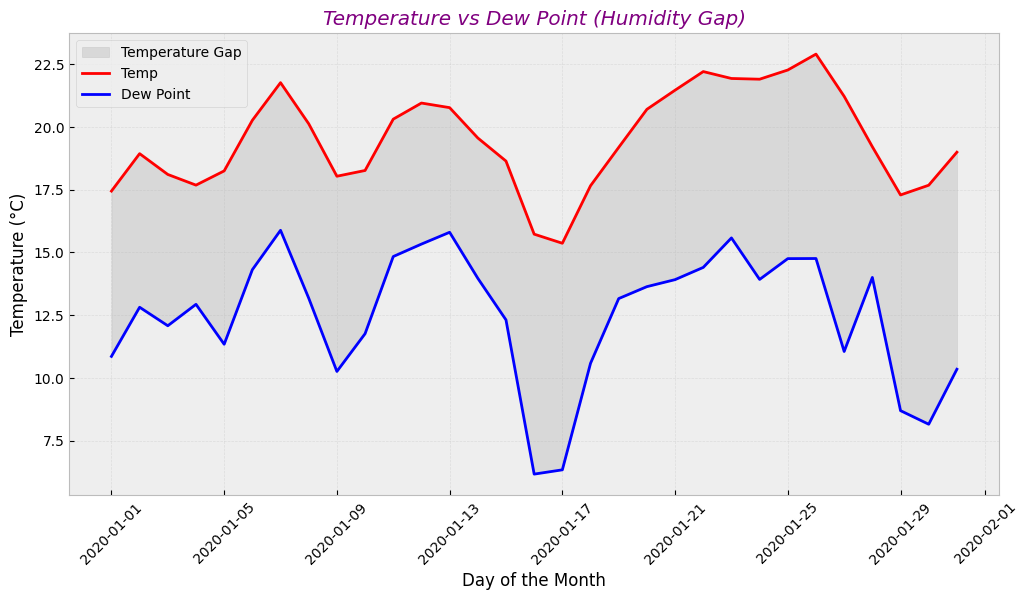

In [122]:
# When "Dew Point" is close to "Temperature," relative humidity is high.
plt.figure(figsize=(12, 6))
sample = daily[(daily['time'].dt.year == 2020) & (daily['time'].dt.month == 1)]
plt.fill_between(sample['time'], sample['temperature'], sample['dew_point'], 
                 color='gray', alpha=0.2, label='Temperature Gap')
plt.plot(sample['time'], sample['temperature'], color='red', label='Temp')
plt.plot(sample['time'], sample['dew_point'], color='blue', label='Dew Point')

plt.title("Temperature vs Dew Point (Humidity Gap)", fontstyle = 'italic', color = 'purple')
plt.xlabel("Day of the Month", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.xticks(rotation = 45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

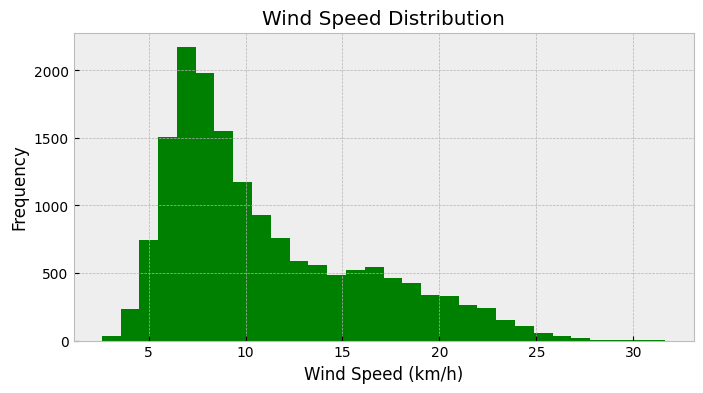

In [120]:
plt.figure(figsize=(8,4))
plt.hist(daily['wind_speed_10m (km/h)'], bins=30, color='green')
plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
plt.style.available

Layer,Composition,Primary Weather Role
Low,Water Droplets,"Rain, Snow, Fog, and heavy shading."
Mid,Water & Ice,Signals changing weather fronts.
High,Ice Crystals,Signals future storms; traps heat.

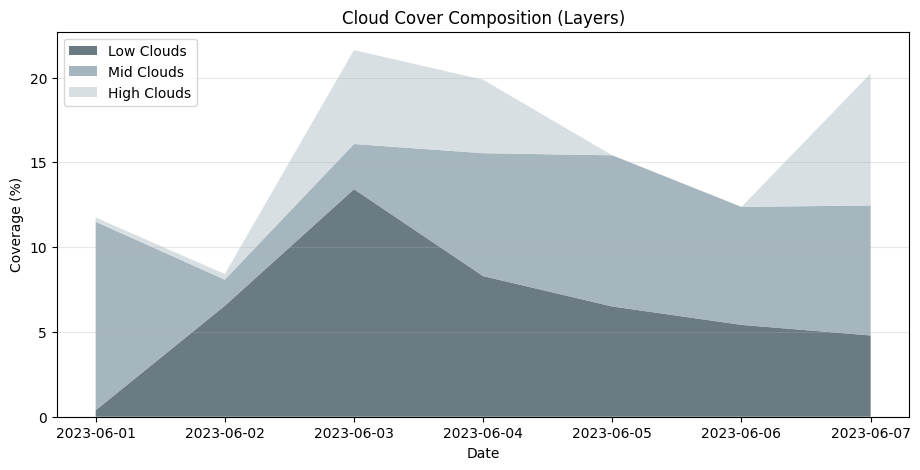

In [128]:
week_sample = daily[(daily['time'] >= '2023-06-01') & (daily['time'] <= '2023-06-07')]

plt.figure(figsize=(11, 5))
plt.stackplot(week_sample['time'], 
              week_sample['cloud_cover_low (%)'], 
              week_sample['cloud_cover_mid (%)'], 
              week_sample['cloud_cover_high (%)'], 
              labels=['Low Clouds', 'Mid Clouds', 'High Clouds'],
              colors=['#455a64', '#90a4ae', '#cfd8dc'], alpha=0.8)

plt.title("Cloud Cover Composition (Layers)")
plt.xlabel("Date")
plt.ylabel("Coverage (%)")
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [145]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec


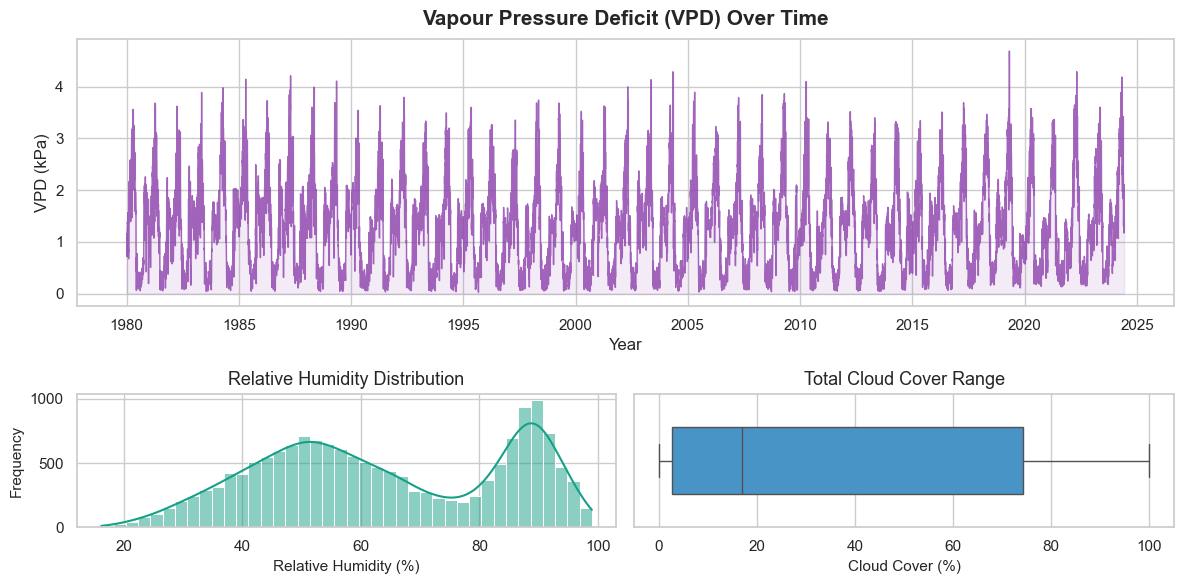

In [156]:
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2, 2, height_ratios=[2, 1], width_ratios=[1, 1], figure = fig)
ax1 = fig.add_subplot(gs[0,:])
ax2 = fig.add_subplot(gs[1,0])
ax3=fig.add_subplot(gs[1,1])
ax1.plot(daily['time'], daily['vapour_pressure_deficit (kPa)'], color='#8e44ad', linewidth=1, alpha=0.8)
ax1.set_title("Vapour Pressure Deficit (VPD) Over Time", fontsize=15, fontweight='bold', pad=10)
ax1.set_ylabel("VPD (kPa)", fontsize=12)
ax1.set_xlabel("Year", fontsize=12)
ax1.fill_between(daily['time'], daily['vapour_pressure_deficit (kPa)'], color='#8e44ad', alpha=0.1)

sns.histplot(daily['relative_humidity'], bins=40, color='#16a085', kde=True, ax=ax2)
ax2.set_title("Relative Humidity Distribution", fontsize=13)
ax2.set_xlabel("Relative Humidity (%)", fontsize=11)
ax2.set_ylabel("Frequency", fontsize=11)

sns.boxplot(x=daily['cloud_cover (%)'], color='#3498db', ax=ax3, width=0.5)
ax3.set_title("Total Cloud Cover Range", fontsize=13)
ax3.set_xlabel("Cloud Cover (%)", fontsize=11)
plt.tight_layout()
plt.show()

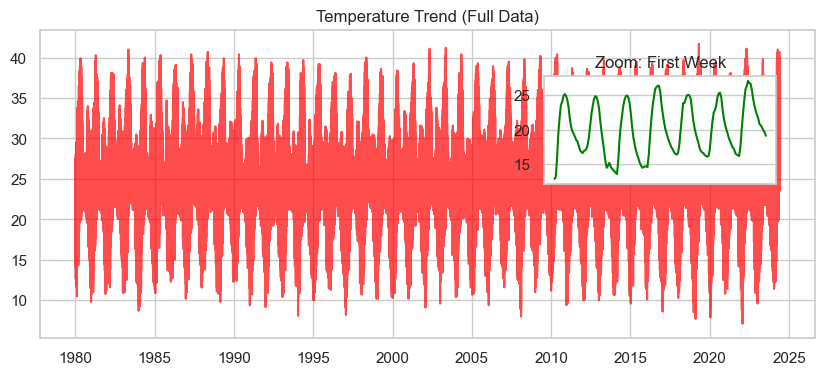

In [163]:
fig, ax = plt.subplots(figsize=(10, 4))
week = df[(df['time'] > '1980-01-01') & (df['time'] < '1980-01-08')]
ax.plot(df['time'], df['temperature'], color='red', alpha=0.7)
ax.set_title("Temperature Trend (Full Data)")
axins = ax.inset_axes([0.65, 0.5, 0.3, 0.35]) 
axins.plot(week['time'], week['temperature'], color='green')
axins.set_title("Zoom: First Week")
axins.set_xticks([])
plt.show()

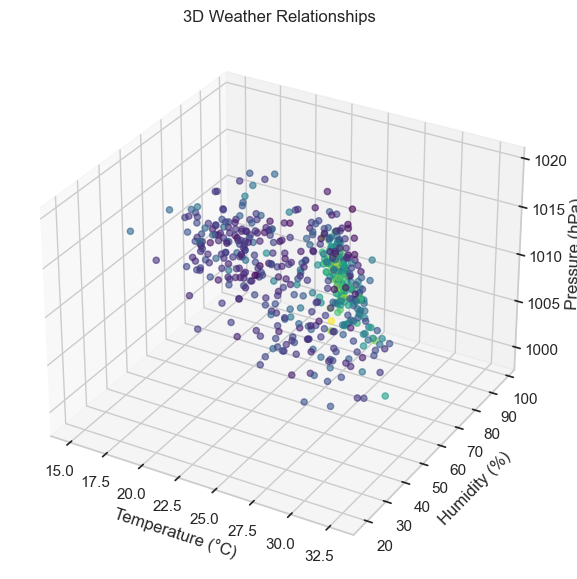

In [166]:
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

sample = daily.sample(500) 
ax.scatter(sample['temperature'], sample['relative_humidity'], sample['pressure_msl (hPa)'],
           c=sample['wind_speed_10m (km/h)'], cmap='viridis', alpha=0.6)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Humidity (%)")
ax.set_zlabel("Pressure (hPa)")
plt.title("3D Weather Relationships")
plt.show()


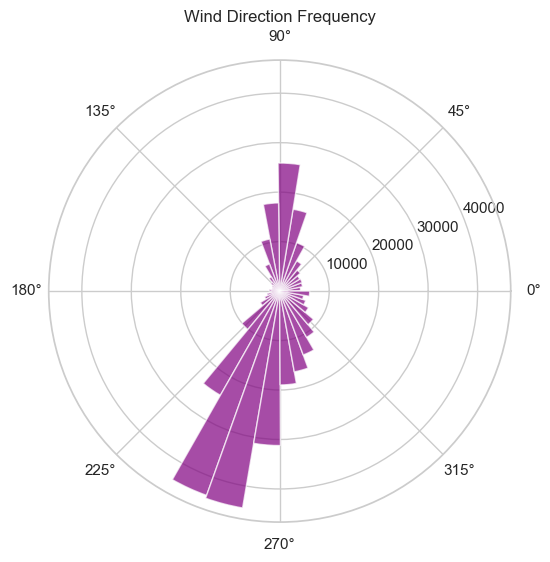

In [172]:
import numpy as np
wind_dir = np.deg2rad(df['wind_direction'])
plt.figure(figsize=(6,6))
plt.subplot(polar=True)
plt.hist(wind_dir, bins=36, color='purple', alpha=0.7)
plt.title("Wind Direction Frequency")
plt.show()


# GridSpec
Col 0,Col 1,Col 2

[0, 0],[0, 1],[0, 2]

[1, 0],[1, 1],[1, 2]

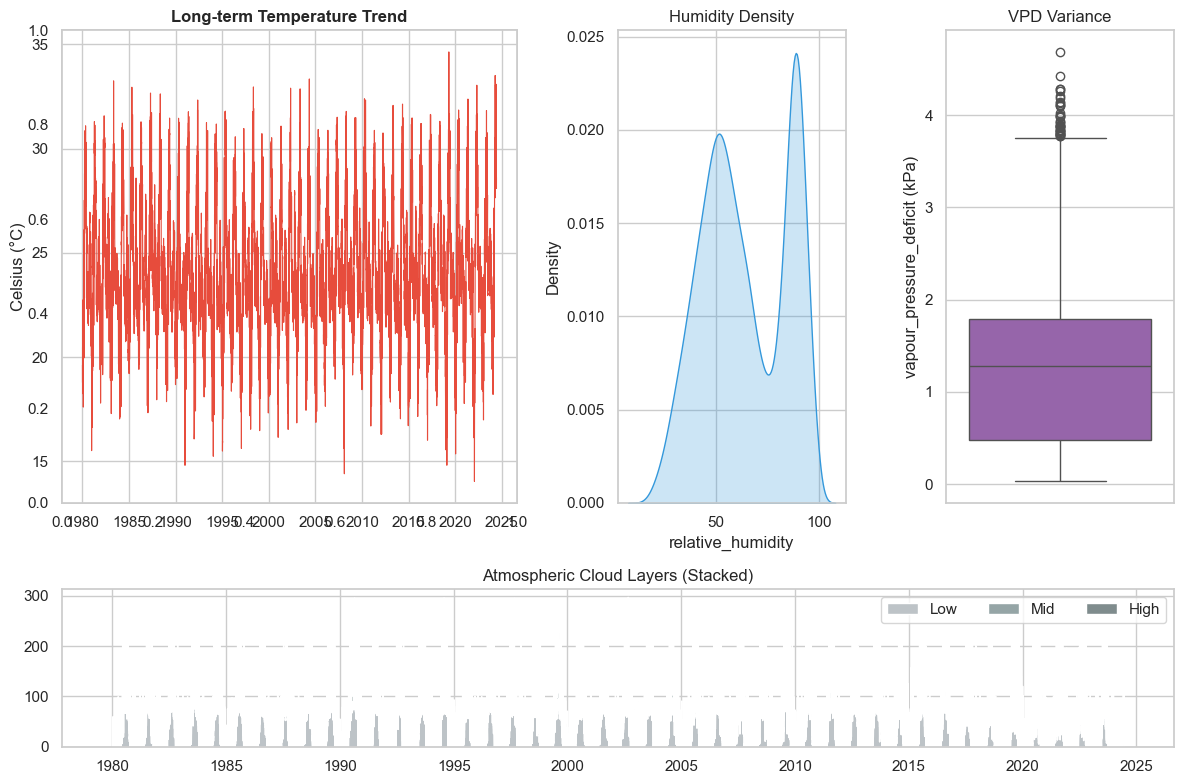

In [186]:
fig = plt.figure(figsize = (12,8))
gs = GridSpec(2,3,height_ratios=[3, 1], width_ratios=[2,1,1],figure=fig)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
ax4 = fig.add_subplot(gs[1,:])
ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(daily['time'], daily['temperature'], color='#e74c3c', linewidth=0.8)
ax1.set_title("Long-term Temperature Trend", fontweight='bold')
ax1.set_ylabel("Celsius (°C)")

sns.kdeplot(daily['relative_humidity'], fill=True, color='#3498db', ax=ax2)
ax2.set_title("Humidity Density")

sns.boxplot(y=daily['vapour_pressure_deficit (kPa)'], color='#9b59b6', ax=ax3)
ax3.set_title("VPD Variance")

ax4.stackplot(daily['time'], 
              daily['cloud_cover_low (%)'], 
              daily['cloud_cover_mid (%)'], 
              daily['cloud_cover_high (%)'], 
              labels=['Low', 'Mid', 'High'], colors=['#bdc3c7', '#95a5a6', '#7f8c8d'])
ax4.set_title("Atmospheric Cloud Layers (Stacked)")
ax4.legend(loc='upper right', ncol=3)

plt.tight_layout()
plt.show()


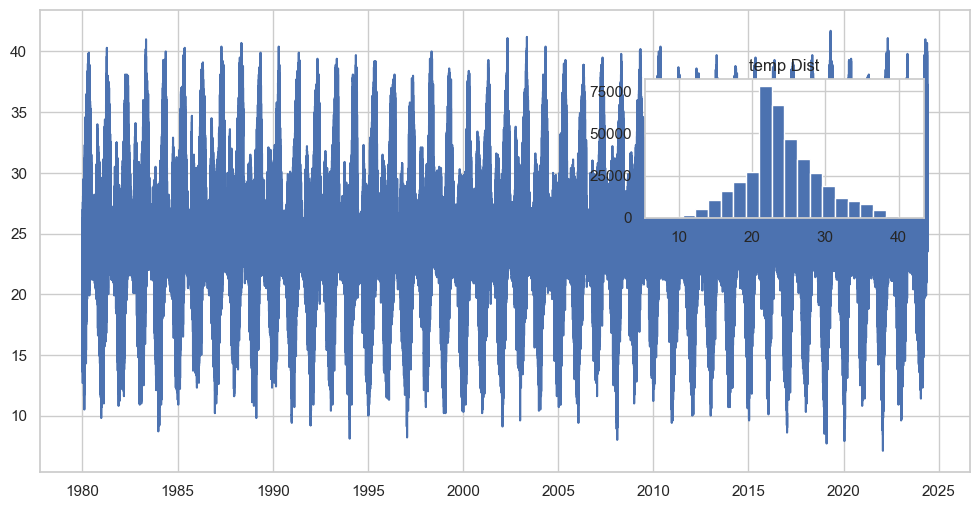

In [193]:
fig = plt.figure(figsize = (12, 6))
gs = GridSpec(1,1,figure=fig)
ax = fig.add_subplot(gs[0])
ax.plot(df['time'], df['temperature'])
insert = ax.inset_axes([0.65, 0.55,0.3,0.3])
insert.hist(df['temperature'], bins = 20)
insert.set_title('temp Dist')
plt.show()

3d Plotting with GridSpec

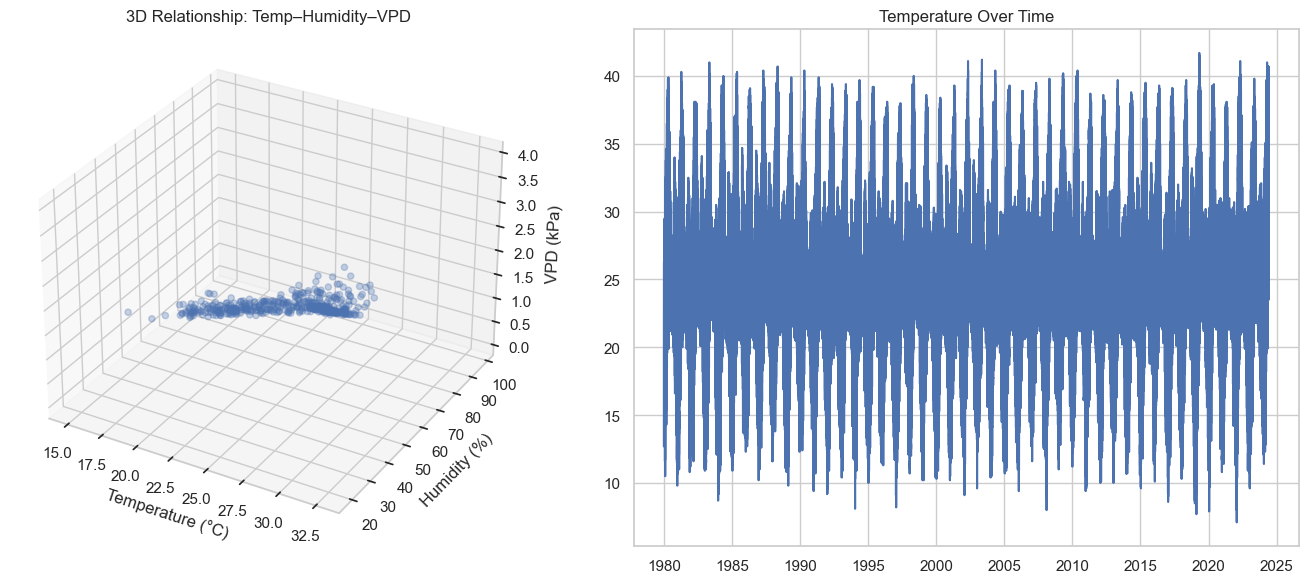

In [198]:
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(1, 2, figure=fig)
ax3d = fig.add_subplot(gs[0,0], projection = '3d')
ax2d = fig.add_subplot(gs[0,1])
ax3d.scatter(
    sample['temperature'],
    sample['relative_humidity'],
    sample['vapour_pressure_deficit (kPa)'],
    alpha=0.3
)

ax3d.set_xlabel("Temperature (°C)")
ax3d.set_ylabel("Humidity (%)")
ax3d.set_zlabel("VPD (kPa)")
ax3d.set_title("3D Relationship: Temp–Humidity–VPD")

ax2d.plot(df['time'], df['temperature'])
ax2d.set_title("Temperature Over Time")

plt.tight_layout()
plt.show()


In [200]:
df.columns

Index(['time', 'temperature', 'relative_humidity', 'dew_point',
       'precipitation (mm)', 'rain (mm)', 'pressure_msl (hPa)',
       'surface_pressure (hPa)', 'cloud_cover (%)', 'cloud_cover_low (%)',
       'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'vapour_pressure_deficit (kPa)', 'wind_speed_10m (km/h)',
       'wind_direction'],
      dtype='str')

In [204]:
sns.set_context("talk")


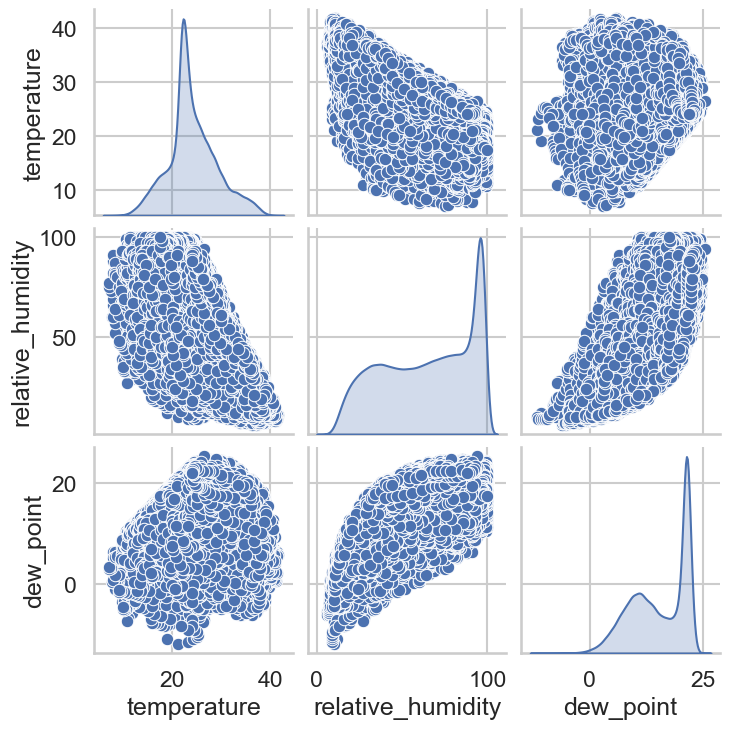

In [205]:
sns.pairplot(
    df[["temperature", "relative_humidity", "dew_point"]],
    diag_kind="kde"
)
plt.show()


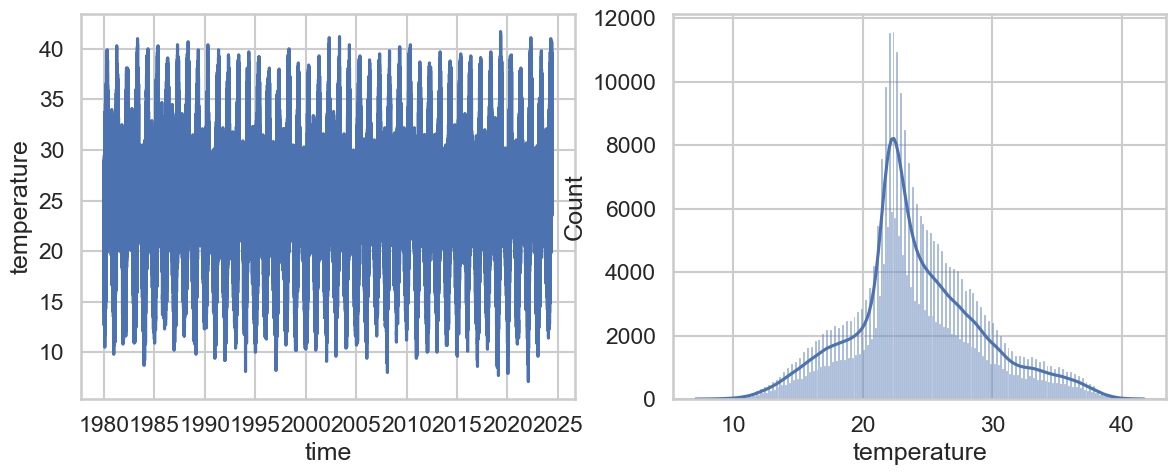

In [209]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df, x="time", y="temperature", ax=ax[0])
sns.histplot(df["temperature"], kde=True, ax=ax[1])

plt.show()


In [214]:
sns.set_palette("magma")

In [218]:
sns.set_context("talk", font_scale=0.8)

In [220]:
sns.set_style("whitegrid")

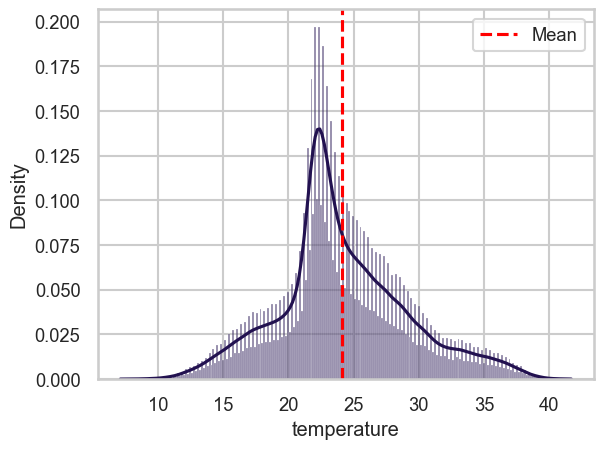

In [221]:
sns.histplot(df['temperature'], kde=True, stat='density')
plt.axvline(df['temperature'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

In [3]:
import seaborn as sns

In [4]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [5]:
df = sns.load_dataset('penguins')
df.shape
df.info()
df.head(2)

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


In [6]:
cols = ['sex', 'species', 'island']
df[cols] = df[cols].astype('category')

In [7]:
df['sex'].value_counts()

sex
Male      168
Female    165
Name: count, dtype: int64

In [16]:
df['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [17]:
df['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [2]:
import matplotlib.pyplot as plt

set_context() - labels, font - paper, notebook(default), talk, poster

set_style() - ticks, whitegrid, darkgrid, white, dark

Palette - Set1(dark), Set2(softer), Set3(mix of dark and soft), deep, muted, bright,pastel, dark, colorblind

Paletter Type - Qualitative(categorical in nature - set1, set2, set3, Dark2), Sequential(ordered progression - Blues, Greens), Diverging(meaningful midpoint - coolwarm, spectral)


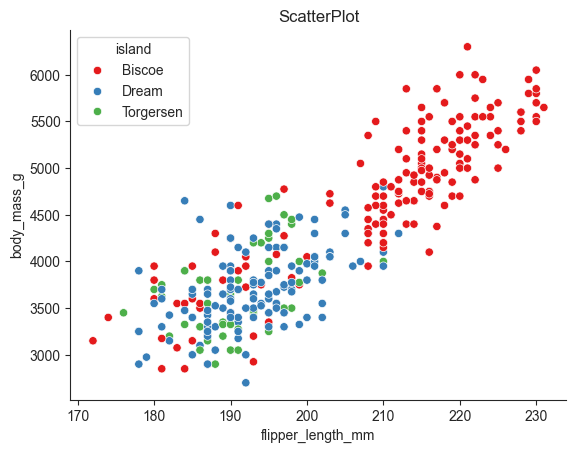

In [38]:
sns.set_style('ticks')
sns.scatterplot(data = df, x = "flipper_length_mm", y = "body_mass_g",hue = 'island', palette = "Set1")
plt.title('ScatterPlot')
sns.despine() # box around plot - left = True
plt.show()

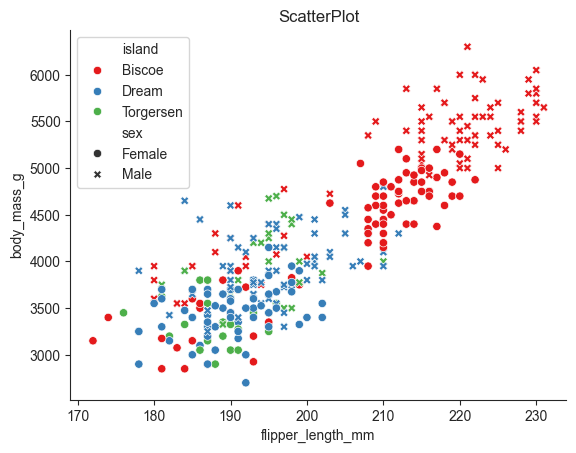

In [51]:
sns.set_style('ticks')
sns.scatterplot(data = df, x = "flipper_length_mm", y = "body_mass_g",hue = 'island', style = 'sex', palette = "Set1")
plt.title('ScatterPlot')
sns.despine() # box around plot - left = True
plt.show()

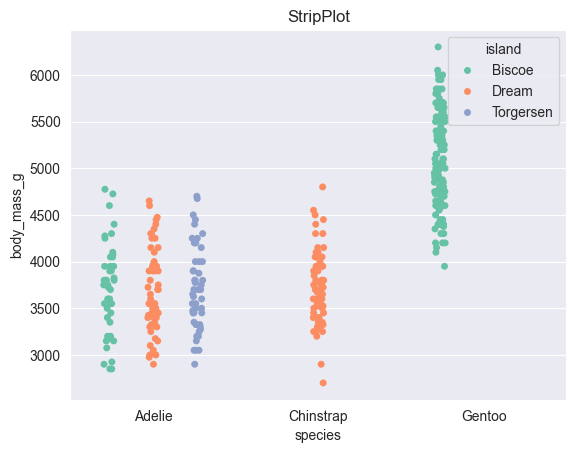

In [52]:
sns.set_style('darkgrid')
sns.stripplot(data = df, x = 'species', y = 'body_mass_g', hue= 'island', jitter = True, dodge = True, palette = 'Set2')
plt.title('StripPlot')
plt.show()

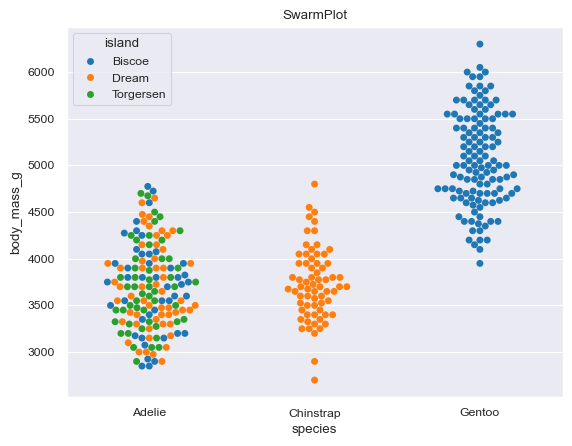

In [55]:
sns.set_context('paper')
sns.set_style('darkgrid')
sns.swarmplot(data = df, x = 'species', y = 'body_mass_g', hue= 'island')
plt.title('SwarmPlot')
plt.show()

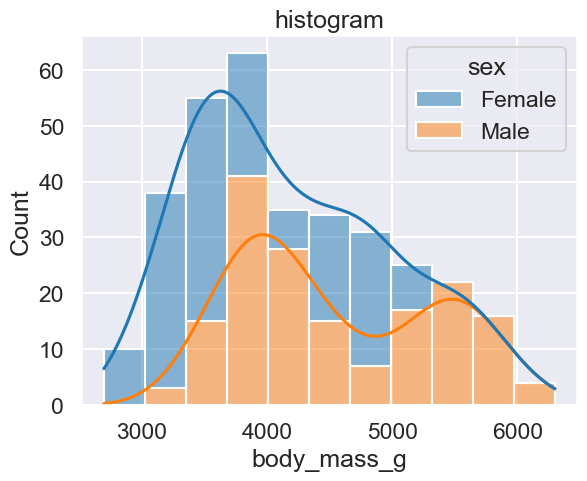

In [44]:
sns.set_context('talk')
sns.set_style('darkgrid')
sns.histplot(data = df, x = 'body_mass_g', hue = 'sex', multiple = 'stack', kde = 'True')
plt.title("histogram")
plt.show()

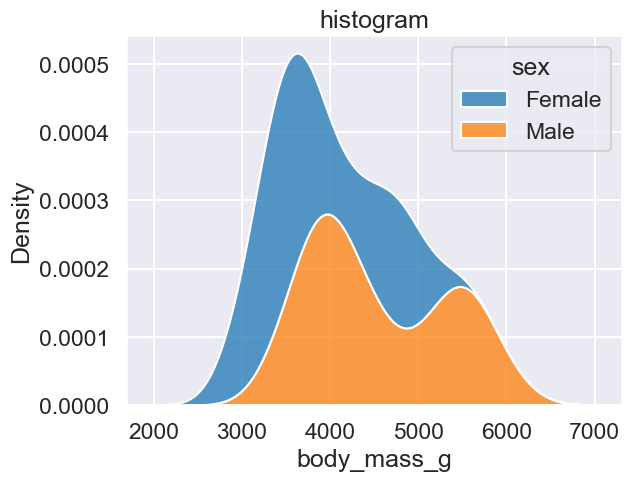

In [47]:
sns.set_context('talk')
sns.set_style('darkgrid')
sns.kdeplot(data = df, x = 'body_mass_g', hue = 'sex', multiple = 'stack', fill = 'True')
plt.title("histogram")
plt.show()

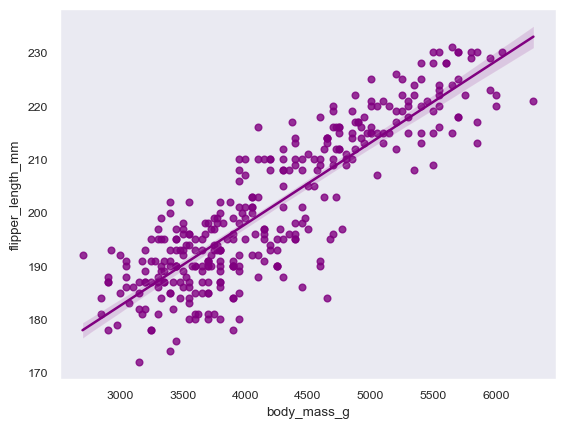

In [69]:
sns.set_context('paper')
sns.set_style('dark')
sns.regplot(data = df, x = 'body_mass_g', y = 'flipper_length_mm', color = 'purple' ) # scatter = false
plt.show()

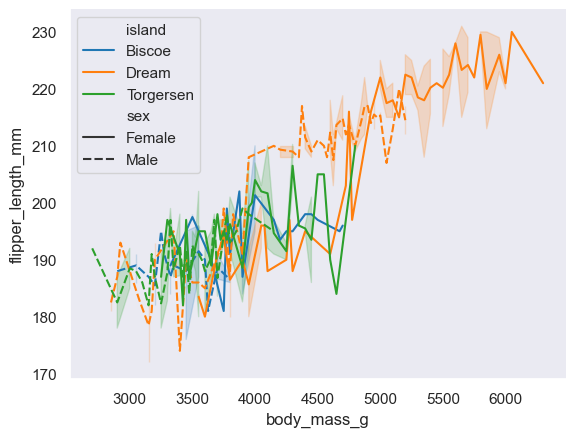

In [72]:
sns.set_context('notebook')
sns.set_style('dark')
sns.lineplot(data = df, x = 'body_mass_g', y = 'flipper_length_mm', hue = 'island', style = 'sex')
sns.despine()
plt.show()

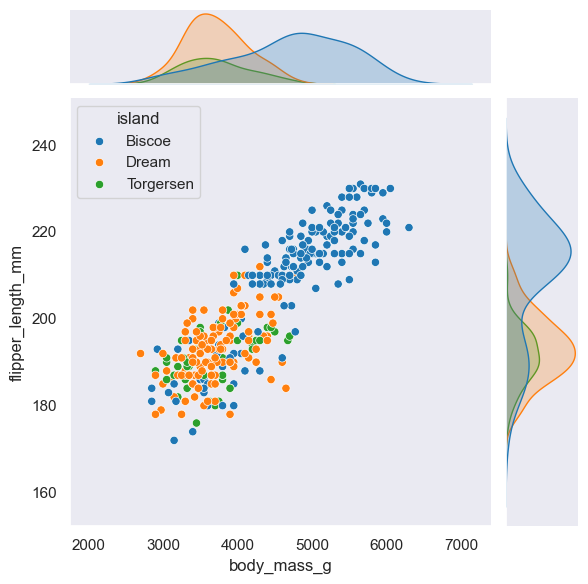

In [83]:
# jointplot
sns.jointplot(data = df, x='body_mass_g', y = 'flipper_length_mm', hue = 'island') #  kind = 'kde'
plt.show()

In [90]:
import numpy as np

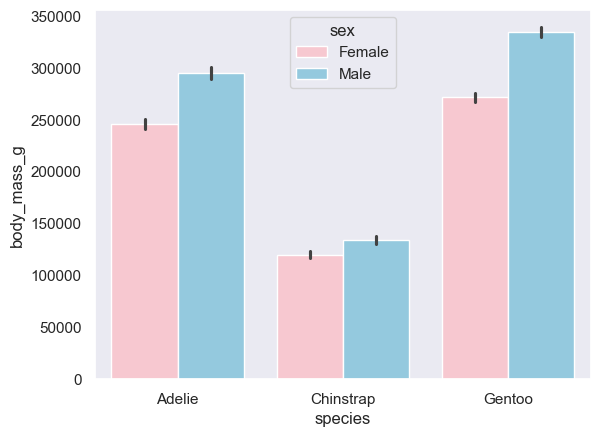

In [92]:
# Bar plot
sns.barplot(data = df, x = 'species', y = 'body_mass_g', hue = 'sex', palette = ['pink', 'skyblue'], estimator = np.sum)
plt.show()

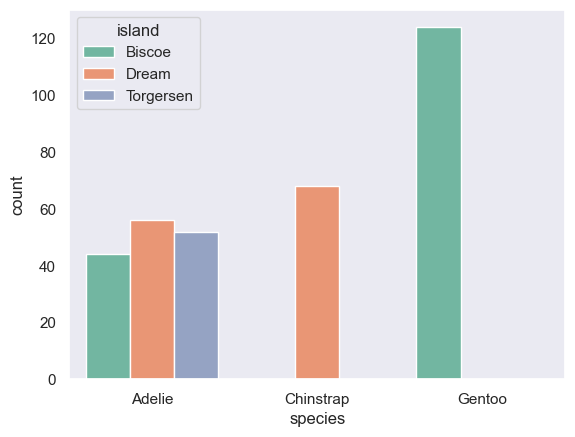

In [96]:
sns.countplot(data=df, x = 'species', palette = 'Set2', hue ='island')
plt.show()

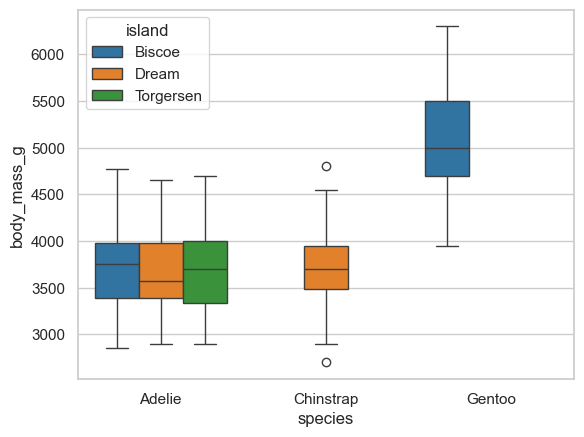

In [ ]:
# Box Plot
sns.set_style('whitegrid')
sns.boxplot(data = df,x = 'species' , y = 'body_mass_g', hue = 'island') # hue = 'sex'
plt.show()

middle - density of data

middle line - median

thick bar - interquartile range ( if inner box)

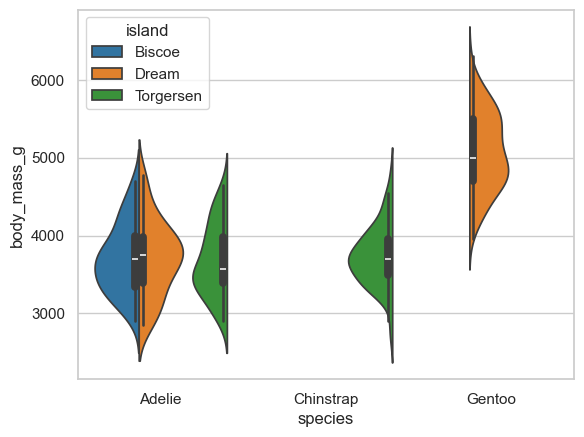

In [104]:
# violin plot
sns.violinplot(data = df,x = 'species' , y = 'body_mass_g', hue = 'island', split = True, inner = "box") # hue = 'sex'
plt.show()

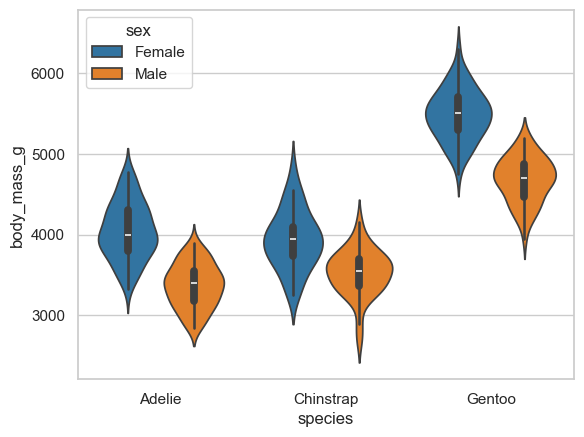

In [101]:
# violin plot
sns.violinplot(data = df,x = 'species' , y = 'body_mass_g', hue = 'sex') # hue = 'island'
plt.show()

C:\Users\sable\AppData\Local\Temp\ipykernel_25372\469534925.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = 'species', y = 'body_mass_g', palette = 'pastel')


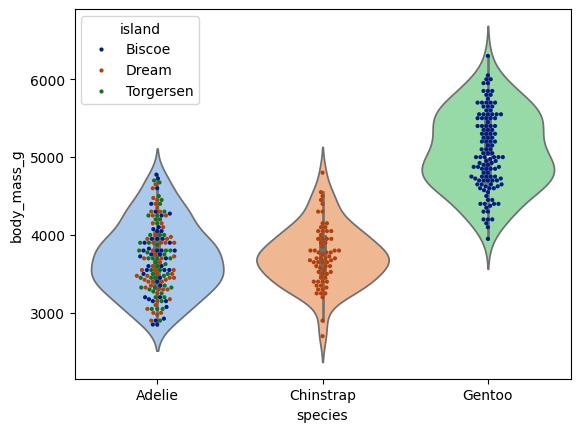

In [12]:
sns.violinplot(data = df, x = 'species', y = 'body_mass_g', palette = 'pastel')
sns.swarmplot(data=df, x = 'species', y = 'body_mass_g', hue = 'island', size = 3, palette = 'dark')
plt.show()

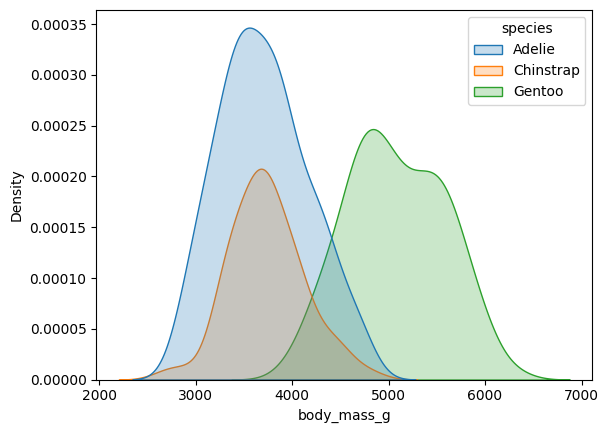

In [14]:
# KDE - for extimating the probability density function of continuous or non-parametric data. A smooth curve that shows the distribution of data - like smoothed out version. It tells where the data is concentrated (peaks) and how it spreads.
sns.kdeplot(data = df, x = 'body_mass_g', hue = 'species', fill = True)
plt.show()

In [18]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

<Axes: >

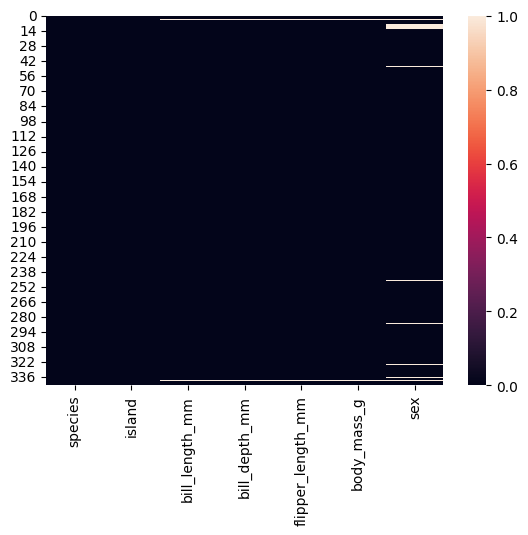

In [17]:
# Heatmap - correlation b/w features, confusion matrix, highlight missing data 
sns.heatmap(df.isnull())


In [20]:
data = df[cols].corr()
data

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


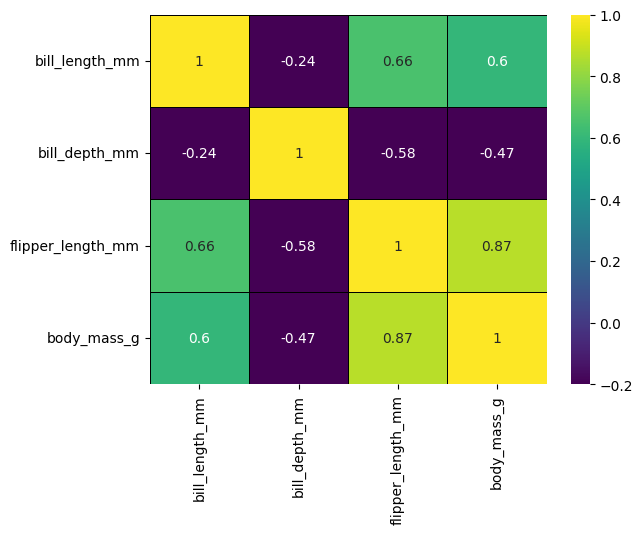

In [26]:
cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
sns.heatmap(data = df[cols].corr(), annot=True, cmap = 'viridis', vmin = -0.2, linewidth = 0.7, linecolor='black' )
plt.show()

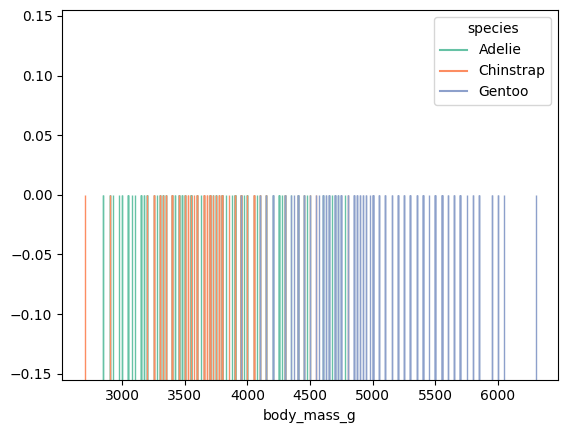

In [30]:
# Rug Plot
sns.rugplot(data = df, x = 'body_mass_g', hue = 'species', palette= 'Set2', height = 0.5)
plt.show()

no hue , no palette

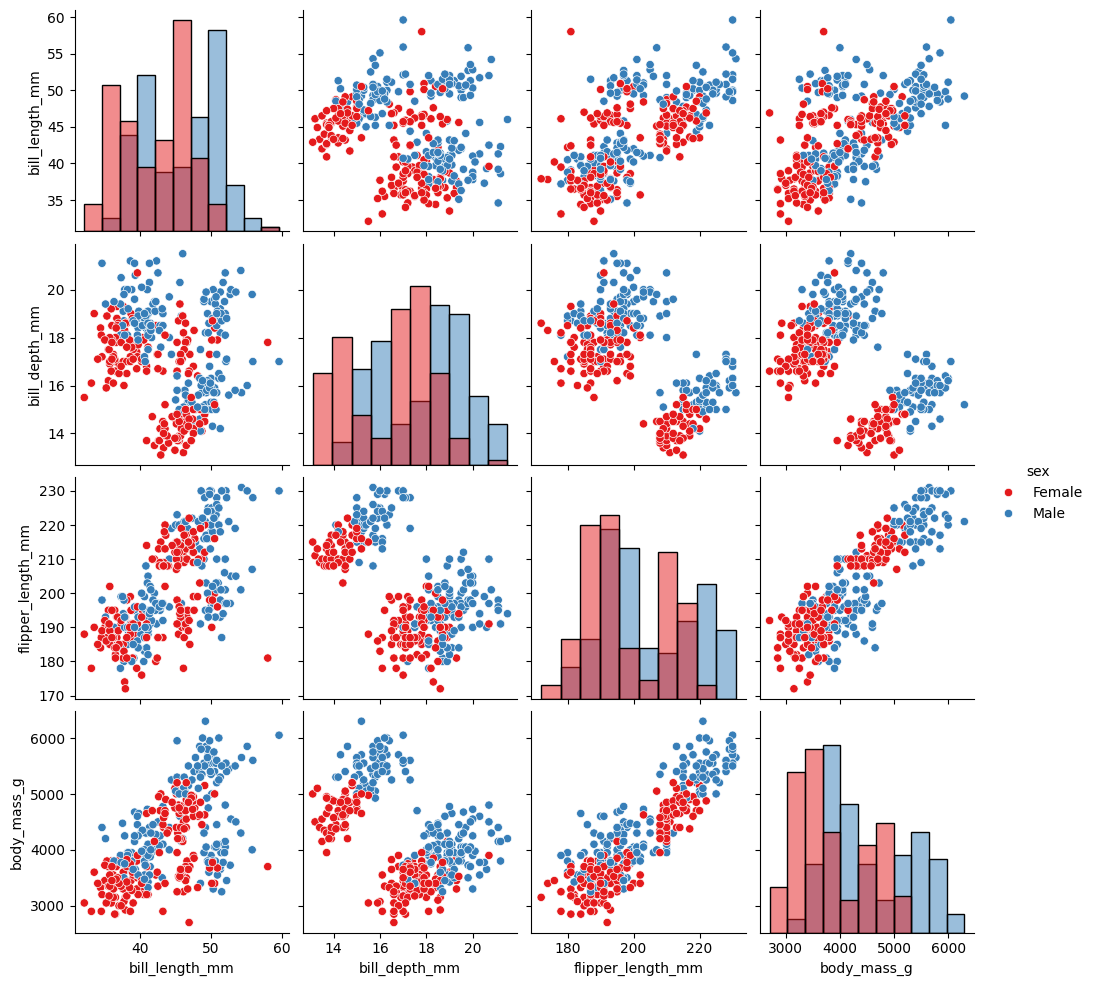

In [39]:
# Pair Plot
sns.pairplot(data = df, hue = "sex",palette = 'Set1', diag_kind='hist') # diag_kind='hist'
plt.show()

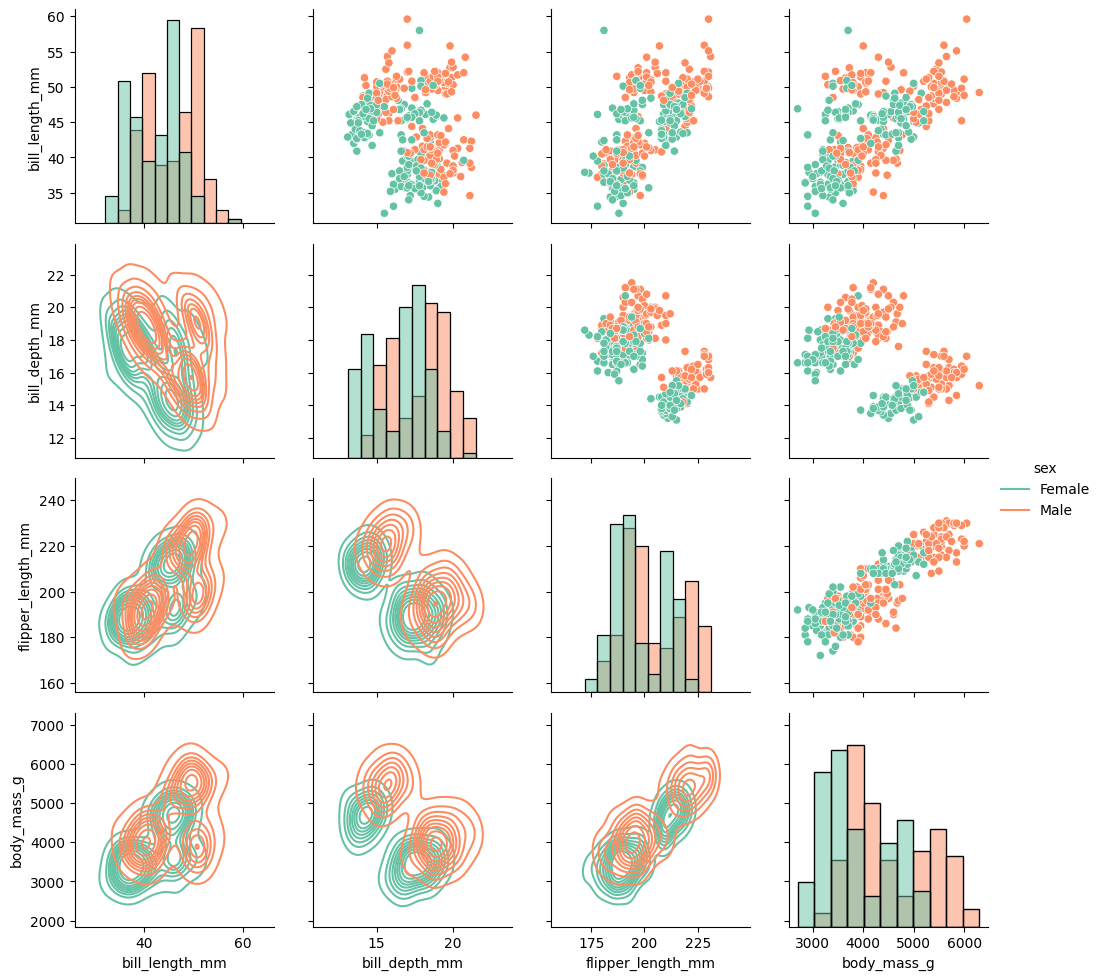

In [42]:
# pair grid -> subplot grid for plotting pariwise relationships in a dataset.
g = sns.PairGrid(data = df, hue = 'sex', palette = 'Set2')
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)
g.add_legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
tips = sns.load_dataset("tips")
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
tips['time'].unique()

['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner']

FacetGrid - Create multiple plots of the same type, split by categories

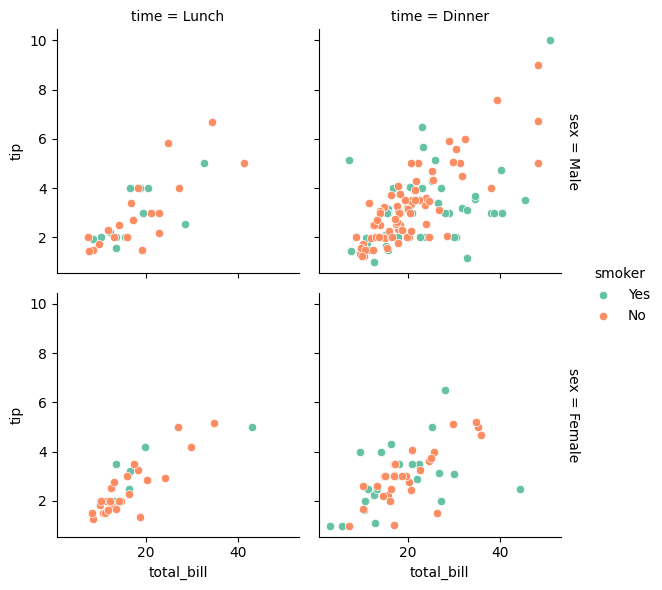

In [25]:
g = sns.FacetGrid(tips, row="sex", col="time",hue = 'smoker', palette = 'Set2',height=3, aspect=1, margin_titles=True)
g.map(sns.scatterplot, "total_bill", "tip")
g.add_legend()
plt.show()


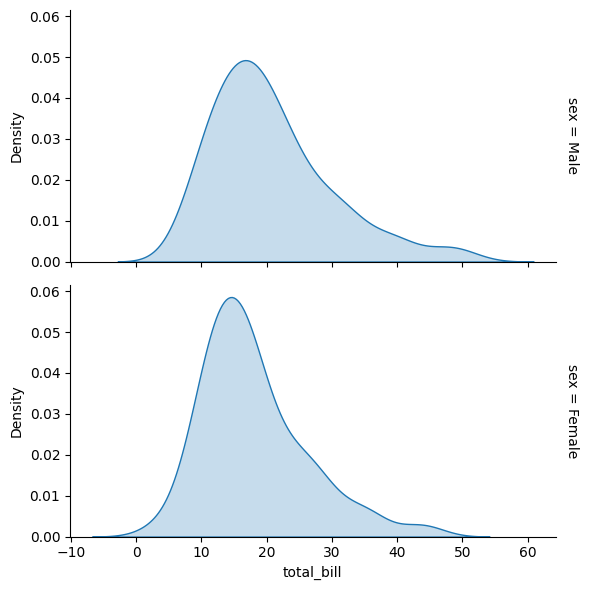

In [22]:
g = sns.FacetGrid(tips, row="sex",height=3, aspect=2, margin_titles=True)
g.map(sns.kdeplot, "total_bill", fill=True)
plt.show()

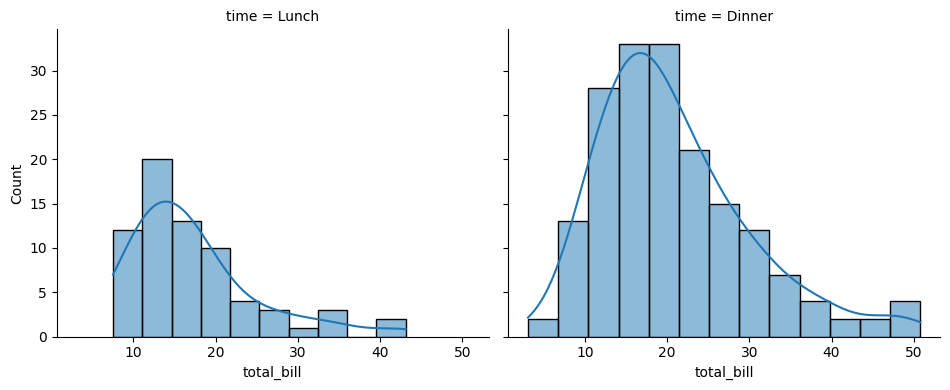

In [28]:
g = sns.FacetGrid(tips, col="time", height=4, aspect=1.2)
g.map(sns.histplot, "total_bill", kde = True)
plt.show()

catplot, displot, pairgrid

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
tips = sns.load_dataset('tips')
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


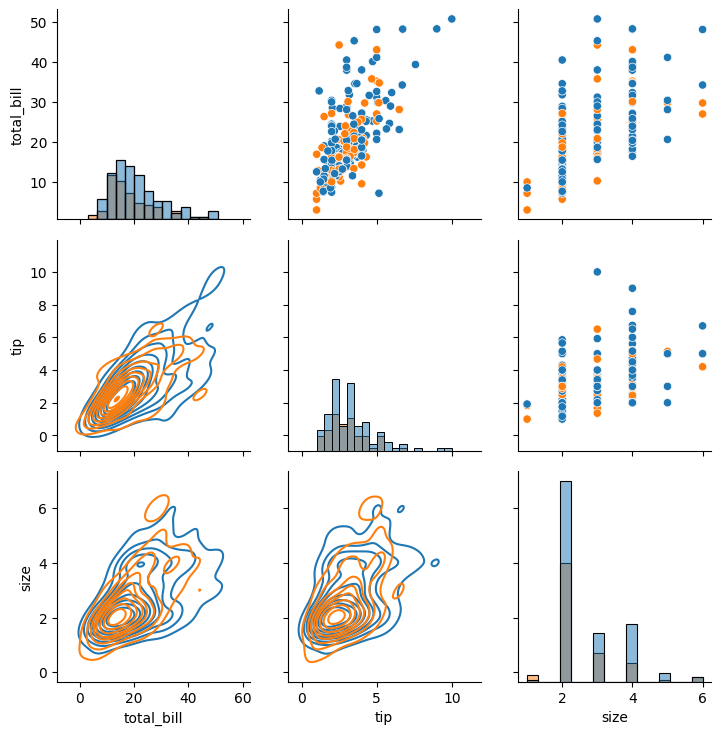

In [ ]:
# pairgrid
g = sns.PairGrid(tips, vars = ['total_bill','tip', 'size'], hue = 'sex')
g.map_diag(sns.histplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
plt.show()

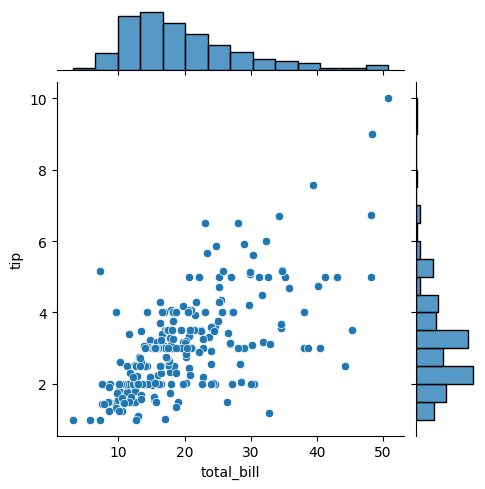

In [77]:
g = sns.JointGrid(data=tips, x='total_bill', y='tip', height=5)
g.plot(sns.scatterplot, sns.histplot)  # main= scatter, margins = histogram
plt.show()

# Figure level objects
FacetGrid - base class for figure level grids.

JointGrid
| Plot              | Description                                              |
| ----------------- | -------------------------------------------------------- |
| `sns.relplot()`   | Scatter or line plots with `row`, `col`, `hue` facets.   |
| `sns.catplot()`   | Categorical plots (bar, box, violin) with facets.        |
| `sns.pairplot()`  | Pairwise scatter plots for multiple numeric columns.     |
| `sns.jointplot()` | Relationship between 2 variables with marginal hist/KDE. |
| `sns.displot()`   | Histogram or KDE plots with row/col facets.              |


# Axes level objects
| Plot                | Description                   |
| ------------------- | ----------------------------- |
| `sns.scatterplot()` | Scatter plot.                 |
| `sns.lineplot()`    | Line plot.                    |
| `sns.barplot()`     | Bar plot.                     |
| `sns.boxplot()`     | Box plot.                     |
| `sns.violinplot()`  | Violin plot.                  |
| `sns.kdeplot()`     | Kernel density estimate plot. |
| `sns.histplot()`    | Histogram/KDE plot.           |


# catplot (figure level plots)
Categorical Plot - It is figure-level function used to visualize.
boxplot,barplot, countplot, stripplot, swarmplot, pointplot, violinplot.

relplot, catplot, pairplot, jointplot, displot are figure level.

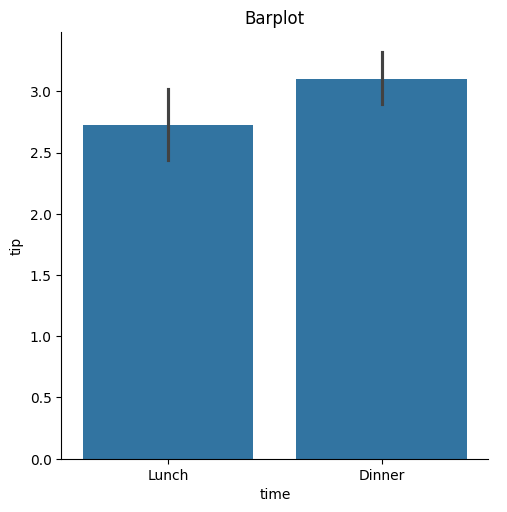

In [29]:
sns.catplot(data=tips, x='time', y = 'tip', kind = 'bar')
plt.title('Barplot')
plt.show()

In [11]:
tips['day'].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']

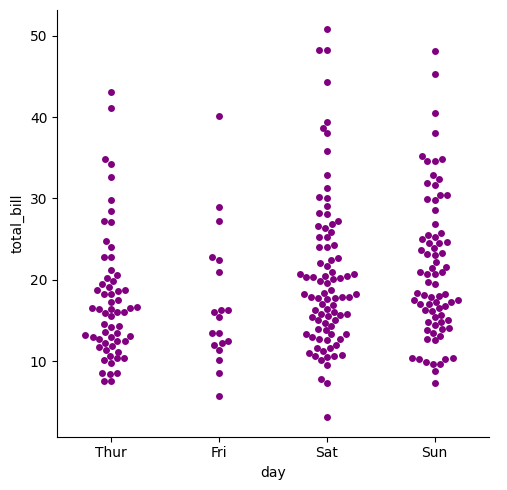

In [98]:
sns.catplot(data=tips, x='day', y = 'total_bill', kind = 'swarm', color='purple')
plt.show()

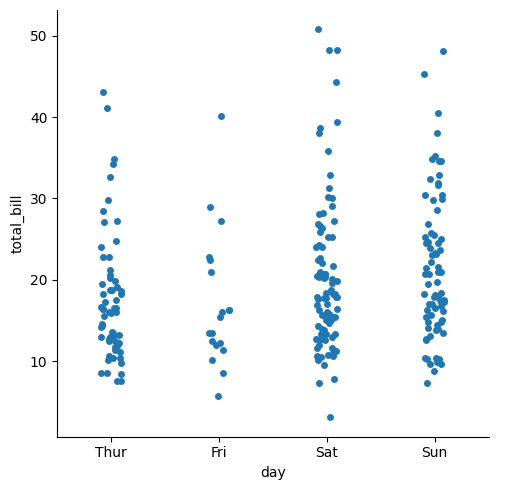

In [9]:
sns.catplot(data=tips, x='day', y = 'total_bill', kind = 'strip')
plt.show()

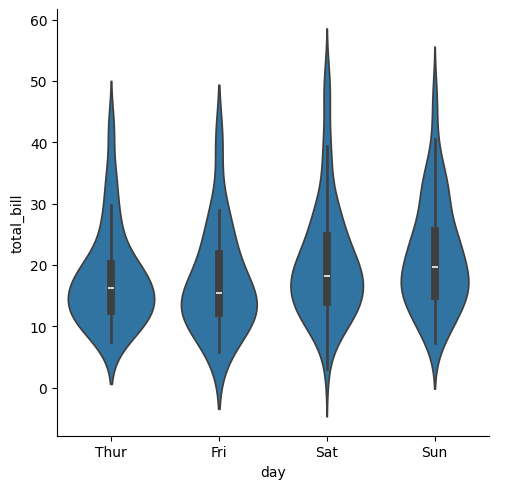

In [12]:
sns.catplot(data = tips, x='day', y='total_bill', kind='violin')
plt.show()

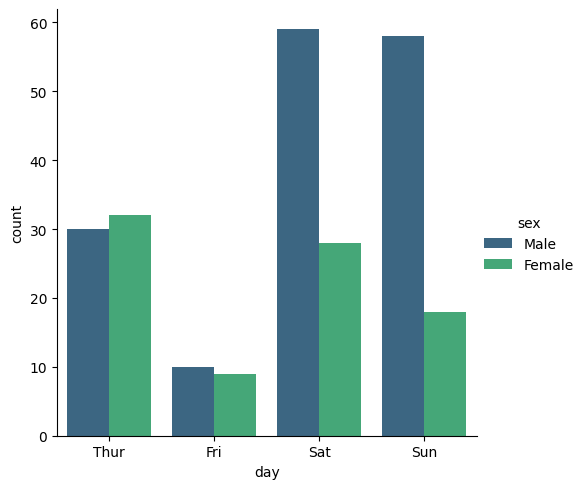

In [32]:
sns.catplot(data= tips, x='day', hue = 'sex', kind = 'count', palette = 'viridis')
plt.show()

C:\Users\sable\AppData\Local\Temp\ipykernel_17712\3586180299.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=tips, x='day', y='total_bill', col='sex', kind = 'box', palette = 'plasma')


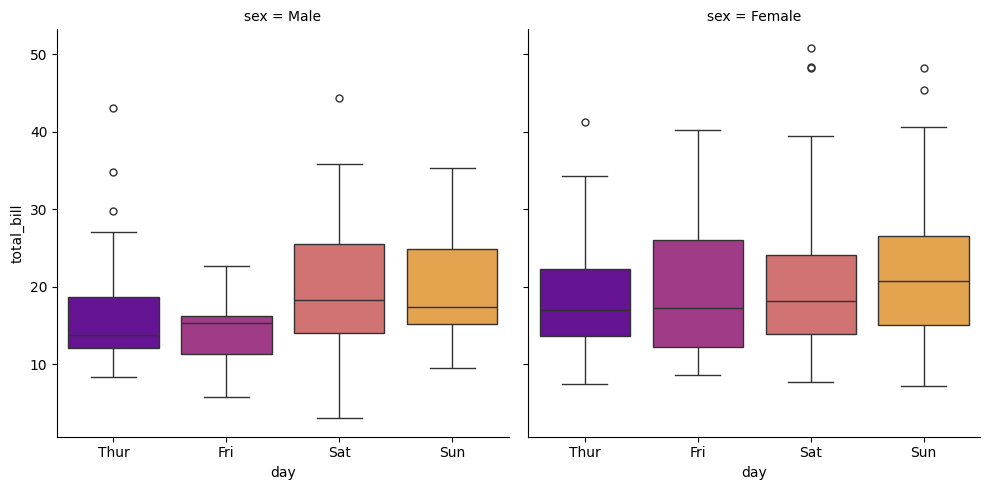

In [96]:
sns.catplot(data=tips, x='day', y='total_bill', col='sex', kind = 'box', palette = 'plasma')
plt.show()

# displot(figure-level) 

Distribution plot (visualize the distribution of a numerical variable)

axes level - histplot, kdeplot, rugplot, violinplot, barplot, lineplot, scatterplot, boxplot.

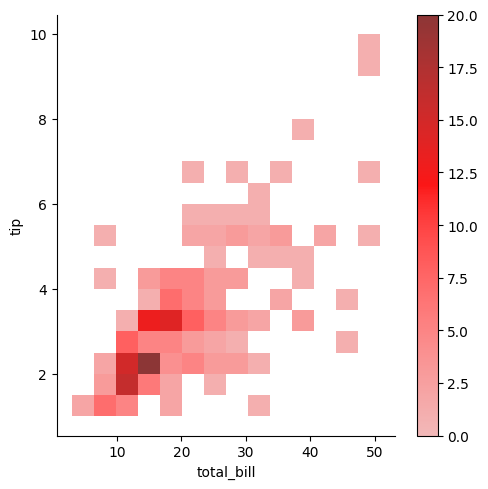

In [37]:
sns.displot(tips, x ='total_bill', y = 'tip', kind = 'hist', color='red', cbar = True)
plt.show()

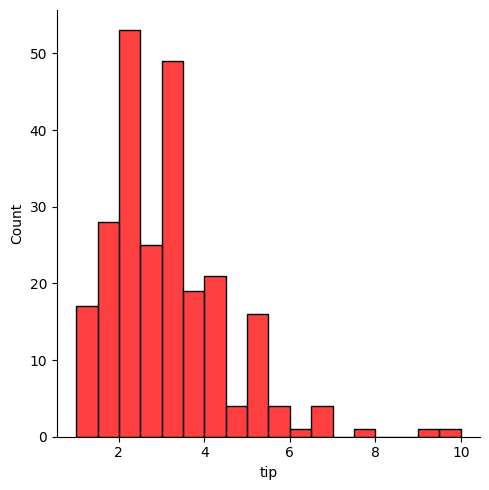

In [38]:
sns.displot(tips, x ='tip', kind = 'hist', color='red')
plt.show()

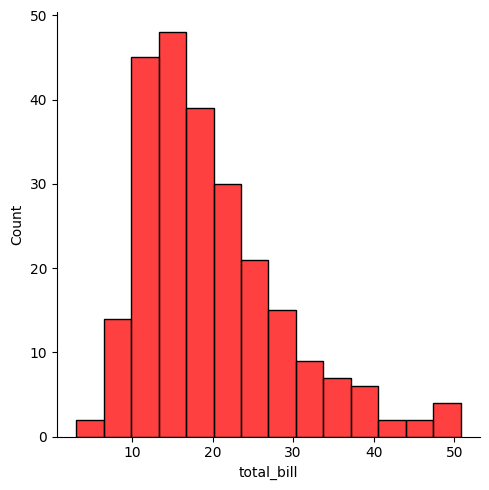

In [26]:
sns.displot(tips, x ='total_bill', kind = 'hist', color='red')
plt.show()

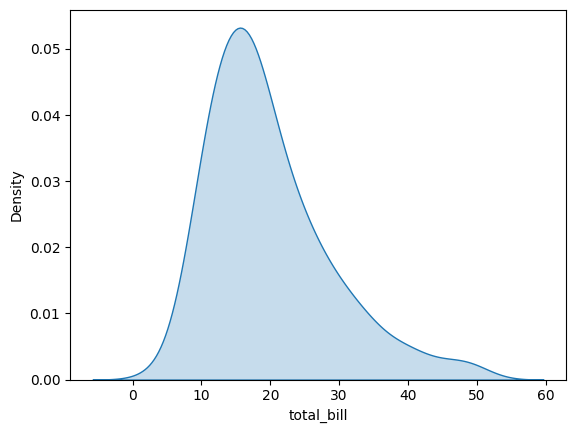

In [42]:
sns.kdeplot(tips, x='total_bill', fill = True)
plt.show()

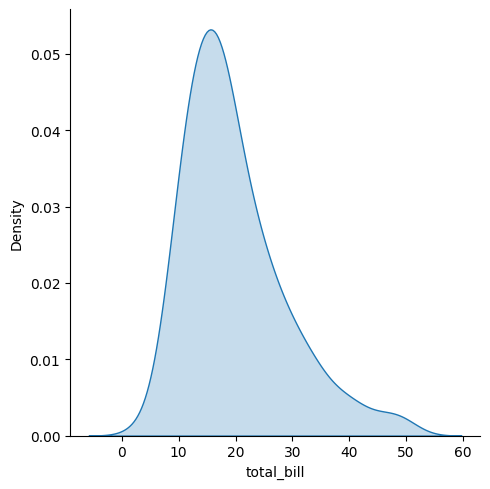

In [18]:
sns.displot(tips, x='total_bill', kind = 'kde', fill = True)
plt.show()

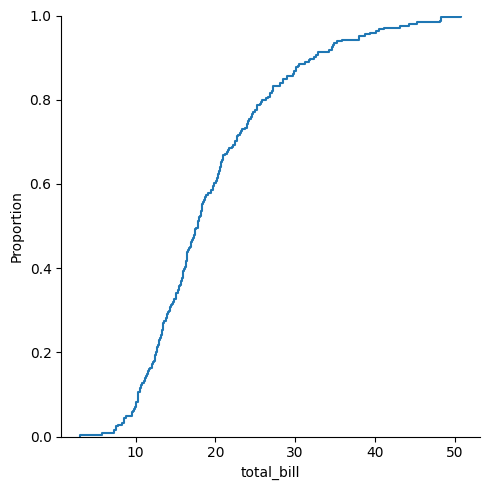

In [19]:
sns.displot(tips, x='total_bill', kind = 'ecdf')
plt.show()

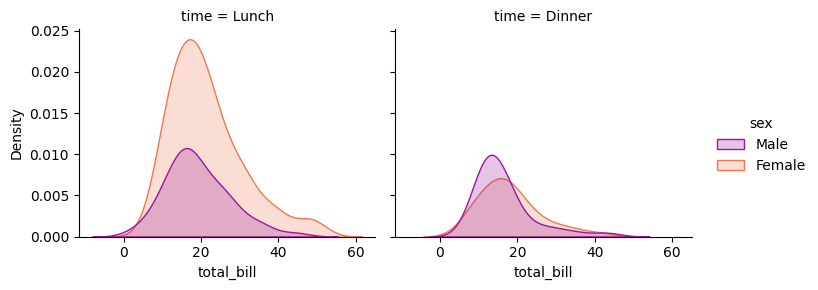

In [49]:
# facetgrid
sns.displot(tips, x='total_bill', col='time', hue = 'sex', kind = 'kde', fill=True, height=3, aspect = 1.2, palette = 'plasma')
plt.show()

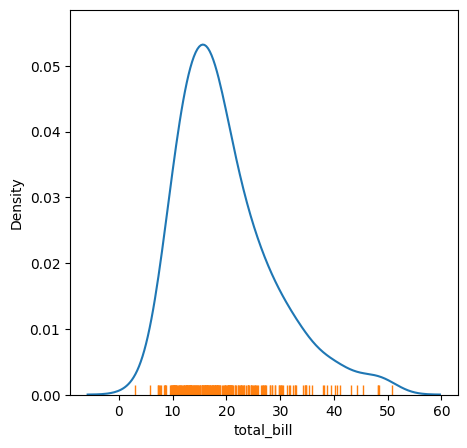

In [70]:
# RugPlot - plot marginal distribution by drawing ticks along the x and y axis. and used with other plots
plt.figure(figsize=(5,5))
sns.kdeplot(data=tips,x = 'total_bill')
sns.rugplot(data=tips, x='total_bill')
plt.show()


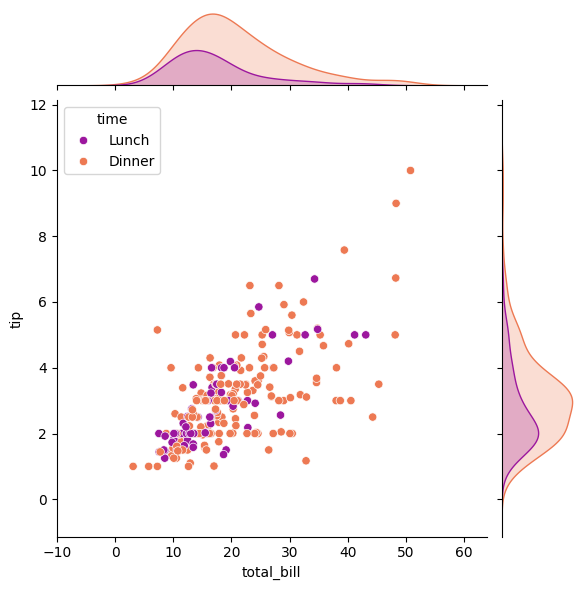

In [82]:
# jointplot - show relationship between two variables with marginal distibution.
sns.jointplot(data=tips, x="total_bill", y="tip", kind = 'scatter', hue = 'time', palette='plasma')
plt.show()


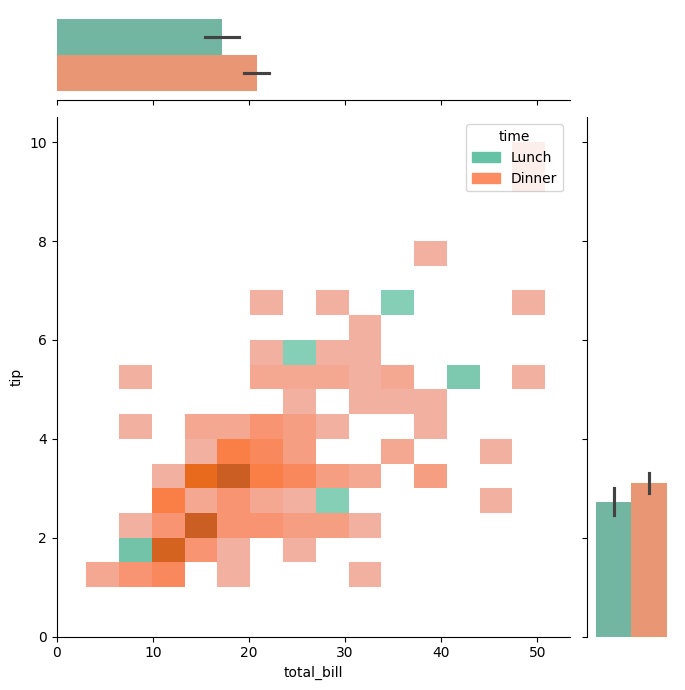

In [94]:
g = sns.JointGrid(data=tips, x='total_bill', y='tip', hue = 'time', palette='Set2', height=7)
g.plot_joint(sns.histplot)     # center plot
g.plot_marginals(sns.barplot)     # side plots

plt.show()


In [60]:
temp = tips.pivot_table(index = 'time', columns = 'sex', values = 'tip', aggfunc='mean')
temp

sex,Male,Female
time,,
Lunch,2.882121,2.582857
Dinner,3.144839,3.002115


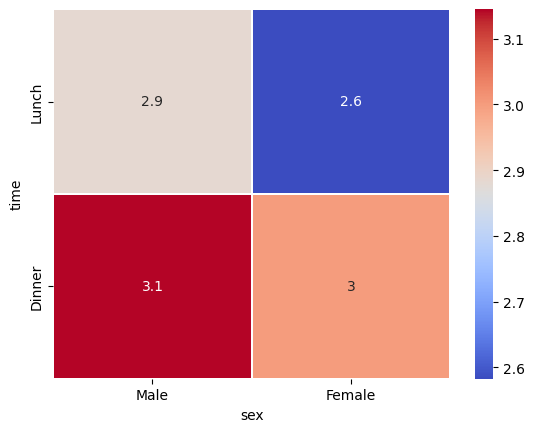

In [65]:
sns.heatmap(temp, annot = True, linewidth = 1.2, cmap = 'coolwarm')
plt.show()

In [ ]:
# Clustermap - similarity / dendrogram / hierarchical agglomerative clustering
df = sns.load_dataset('iris')
df.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


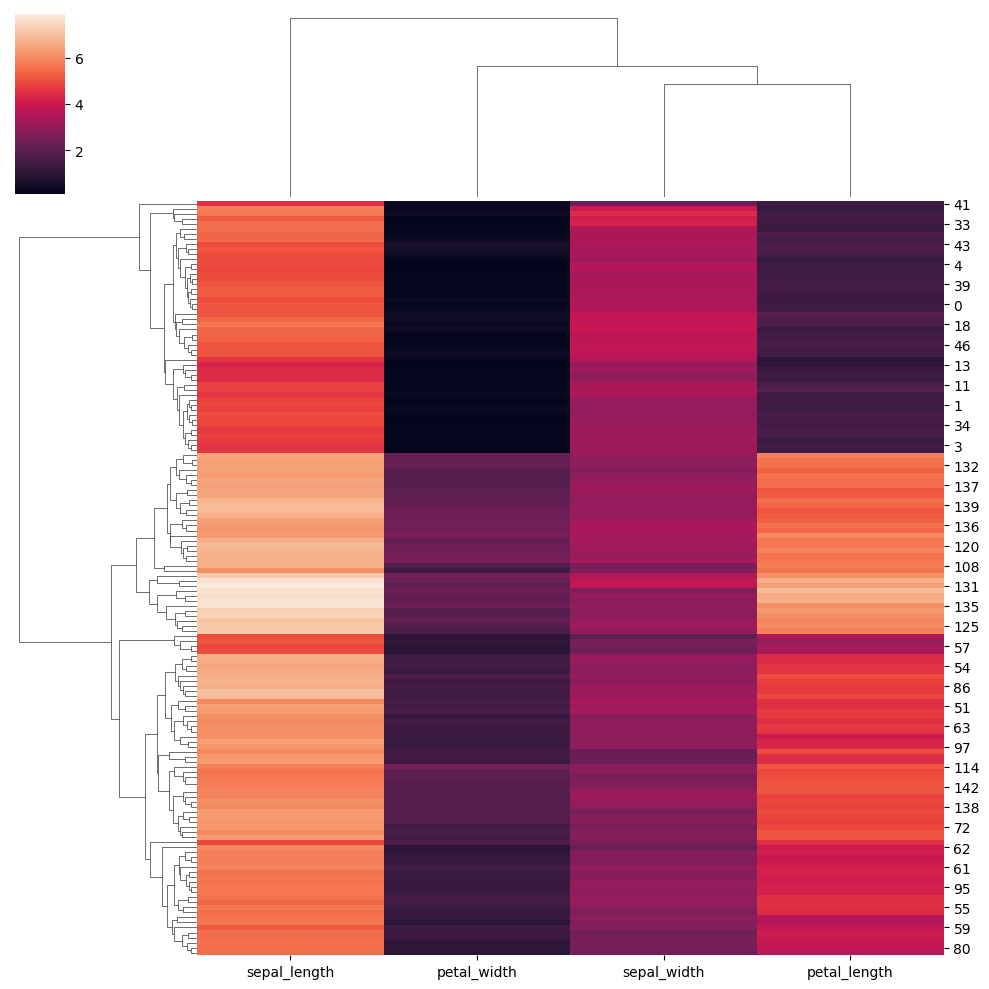

In [68]:
sns.clustermap(df.iloc[:, [0,1,2,3]])
plt.show()

facetgrid(.map) is low level and need of map but in relplot(relational plot, kind) it is high level and no need of map function which creates facetgrid internally

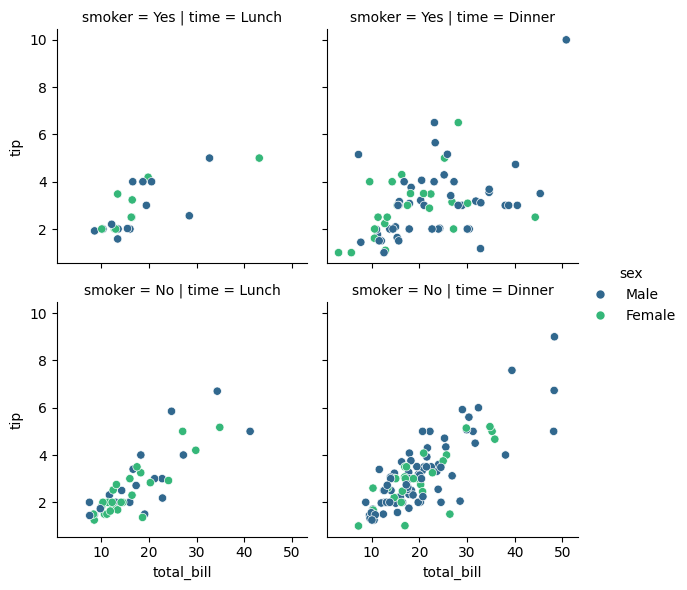

In [74]:
# relplot - figure level
sns.relplot(data=tips, x = 'total_bill', y = 'tip', row = 'smoker', col = 'time', hue = 'sex', palette = 'viridis', height = 3, aspect = 1, kind = 'scatter')
plt.show()